In [1]:
from fastai.vision.all import *

In [2]:
path = untar_data(URLs.PETS)

path.ls()

<div><progress max="811706944" value="811712512"></progress> 100.00% [811712512/811706944 00:18&lt;00:00]</div>

[Path('/root/.fastai/data/oxford-iiit-pet/annotations'), Path('/root/.fastai/data/oxford-iiit-pet/images')]

In [3]:
files = get_image_files(path/"images")

len(files)

7390

In [4]:
files[0], files[6]

(Path('/root/.fastai/data/oxford-iiit-pet/images/shiba_inu_205.jpg'),
 Path('/root/.fastai/data/oxford-iiit-pet/images/Ragdoll_136.jpg'))

In [5]:
def label_func(f): return f[0].isupper()

In [6]:
dls = ImageDataLoaders.from_name_func(path, files, valid_pct=0.2, seed=42, label_func=label_func, item_tfms=Resize(224))

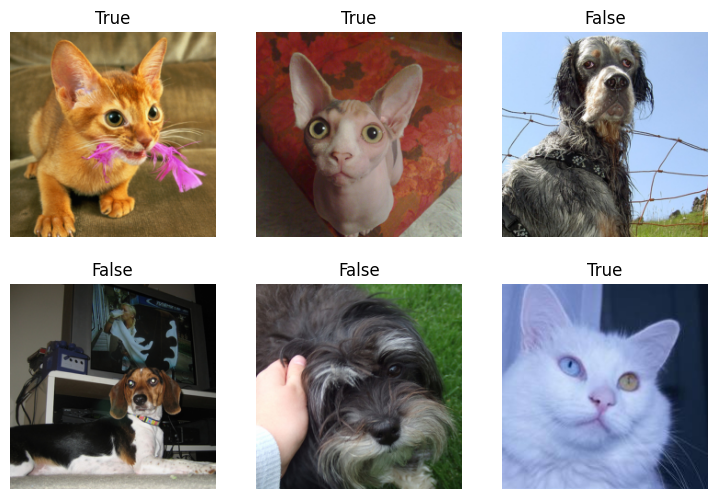

In [7]:
dls.show_batch(max_n=6)

In [8]:
learn = vision_learner(dls, resnet34, metrics=error_rate)
learn.fine_tune(1)

Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 187MB/s] 


epoch,train_loss,valid_loss,error_rate,time
0,0.150647,0.016579,0.006089,08:19


epoch,train_loss,valid_loss,error_rate,time
0,0.075012,0.021524,0.008796,12:13
